# 📘 Overview General del Dataset

Este notebook realiza un análisis inicial para entender el estado actual del negocio de venta de jerseys. Se realiza limpieza mínima, se calculan métricas globales y se presenta una breve conclusión ejecutiva.


In [5]:
# Importar librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt

# configuración sencilla de visualización
target_csv = "data_jerseys_cleaned.csv"

In [6]:
# cargar dataset
df = pd.read_csv(target_csv, parse_dates=['Fecha de compra','Fecha llegada','Fecha de venta'])

# limpieza mínima: eliminar duplicados exactos
df = df.drop_duplicates()

# mostrar algunas filas
df.head()

,Pedido,Fecha de compra,Fecha llegada,Tiempo en llegar,Fecha de venta,equipo,deporte,version,temporada,Jugador,Talla,Proveedor,Costo,Costo de envio,Costo total,Venta,Ganancia
0,8,2025-09-10,2025-10-14,34,2026-01-19,Portugal,Futbol,Retro,Retro,Sin nombre,L,Alibaba,8.8,4.11,12.91,34.11,21.20
1,1,2025-06-12,2025-07-03,21,2025-07-03,FC Barcelona,Futbol,Local,2025/2026,LAMINE YAMAL,L,Alibaba,11.0,6.00,17.00,48.19,31.19
3,1,2025-06-12,2025-07-03,21,2025-07-03,Real Madrid,Futbol,Local,2025/2026,MBAPPE,L,Alibaba,10.5,6.00,16.50,40.00,23.50
4,1,2025-06-12,2025-07-03,21,2025-07-05,Real Madrid,Futbol,Local,2025/2026,Sin nombre,XL,Alibaba,10.5,6.00,16.50,32.20,15.70
5,1,2025-06-12,2025-07-03,21,2025-07-06,FC Barcelona,Futbol,Local,2025/2026,PEDRI,L,Alibaba,10.5,6.00,16.50,37.57,21.07


In [9]:
# cálculos principales
num_registros = len(df)
fecha_min = df['Fecha de compra'].min()
fecha_max = df['Fecha de compra'].max()
total_jerseys = df.shape[0]  # registro por jersey

total_ingresos = df['Venta'].sum()
total_ganancia = df[df['Ganancia']>0]['Ganancia'].sum() 
precio_promedio = df['Venta'].mean()
ganancia_promedio = df[df['Ganancia']>0]['Ganancia'].mean()  # solo considerar ventas con ganancia positiva
jerseys_vendidos=df[df['Venta']>0].shape[0]  # contar solo registros con venta positiva


# mostrar resultados
df_metrics = pd.DataFrame({
    'Métrica': ['Registros','Fecha inicio','Fecha fin','Jerseys vendidos',
               'Ingresos totales','Ganancia total','Precio medio venta','Ganancia media'],
    'Valor': [num_registros, fecha_min, fecha_max, jerseys_vendidos,
              total_ingresos, total_ganancia, precio_promedio, ganancia_promedio]
})
df_metrics

,Métrica,Valor
0,Registros,183
1,Fecha inicio,2025-06-12 00:00:00
2,Fecha fin,2026-02-06 00:00:00
3,Jerseys vendidos,158
4,Ingresos totales,5004.49
5,Ganancia total,2614.86
6,Precio medio venta,31.278063
7,Ganancia media,16.655159


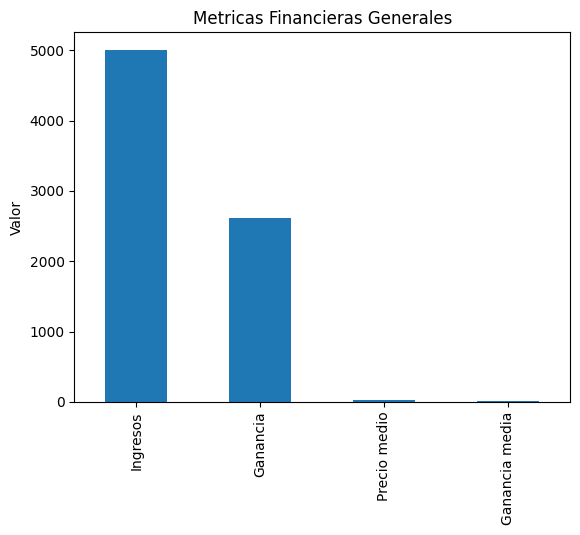

In [8]:
# visualización simple: barras de ingresos y ganancia
metrics_plot = pd.Series({'Ingresos': total_ingresos, 'Ganancia': total_ganancia, 'Precio medio': precio_promedio, 'Ganancia media': ganancia_promedio})
metrics_plot.plot(kind='bar', title='Metricas Financieras Generales')
plt.ylabel('Valor')
plt.show()

## Conclusión ejecutiva

El dataset contiene **{:,}** registros de jerseys (desde {} hasta {}).  
Se vendieron un total de **{:,} jerseys** generando **{:.2f}** en ingresos y **{:.2f}** en ganancia.  
El precio de venta promedio es **{:.2f}**, con una ganancia promedio de **{:.2f}** por unidad.

En resumen, el negocio ya ha movido volumen y genera márgenes positivos promedio. Las cifras muestran una base sólida para análisis más profundos en las siguientes secciones.